### **Challenge 5** — Orchestrator-Worker with Send API

### What to build:
A research agent that takes 3 topics, dispatches them to parallel research workers using Send, then combines all results into one final report.

### What it should do:

- User provides a subject (e.g. "AI Engineering")
- Orchestrator node generates 3 subtopics from it
- Send dispatches each subtopic to a research worker in parallel
- Each worker writes a short paragraph about its topic
- Combiner node merges all 3 results into one report

### Constraints:

- Use Send from langgraph.types — not regular edges for the parallel part
- Use Annotated[list, operator.add] as the reducer for collecting worker results
- Orchestrator and worker must have different state schemas — use subgraph pattern

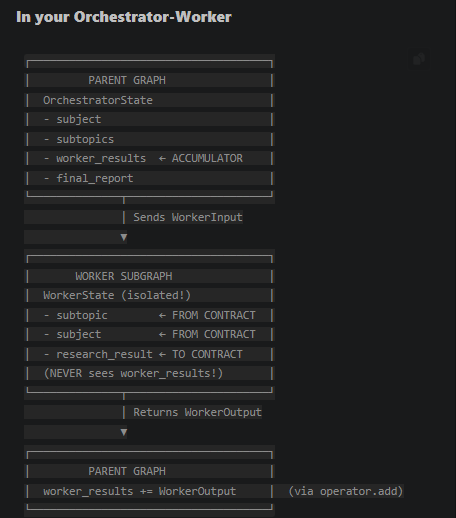

In [ ]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import Send, interrupt, Command
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing import TypedDict, Annotated, List
import operator
import uuid
import json

load_dotenv()

True

In [10]:
# Initialize LLM
llm = init_chat_model(
    model="qwen/qwen3.8-27b",       # The specific Groq model ID
    model_provider="groq",        # Specifies the provider
    temperature=0                 # Optional parameters
)

In [11]:
# state defination

# input
class WorkerInput(TypedDict):
    subject: str
    subtopic: str

# output
class WorkerOutput(TypedDict):
    worker_result: str
    subtopic: str
    
# overall state
class WorkerState(WorkerInput, WorkerOutput):
    pass

# private state (Orchestrator state)
class OrchestratorState(TypedDict):
    subject: str
    subtopic: str
    work_result: Annotated[List[dict],operator.add ] #  ← ACCUMULATOR 
    final_result: str


In [ ]:
# WORKER
def ResearchWorker(State: WorkerState) -> WorkerOutput:
    subject = State['subject']
    subtopic = State['subtopic']

    # prompt
    prompt = f"""You are a research assistant. Write a concise, informative paragraph (3-5 sentences) about:
    Subtopic: {subtopic}
    Context: Part of research on "{subject}."""

    response = llm.invoke([SystemMessage(content="You are a knowledgeable research assistant."),
                           HumanMessage(content=prompt)
                           ])

    return {
        "response_content": response,
        "subtopic": subject
    }

# create worker workflow
worker_builder = StateGraph(WorkerState,
                            input_schema=WorkerInput,
                            output_schema=WorkerOutput)
worker_builder.add_node('research',ResearchWorker)
worker_builder.add_edge(START, 'research')
worker_builder.add_edge('research', END)

# last step
worker_subgraph = worker_builder.compile()

# test_result = worker_subgraph.invoke({"subtopic": "RAG systems", "subject": "AI Engineering"})
# print(test_result)

{'subtopic': 'AI Engineering'}


In [ ]:
# Orchestrator node
def Orchestrator(state: OrchestratorState) -> dict:
    subject = state['subject']

    prompt = f"""Given the subject: "{subject}"
    Generate exactly 3 distinct, specific subtopics that would be valuable to research.
    Return as a JSON list of strings, e.g., ["subtopic 1", "subtopic 2", "subtopic 3"]
    Make them technical and non-overlapping."""

    respone = llm.invoke([
        SystemMessage(content='You generate focused research subtopics. Output only a JSON list.'),
        HumanMessage(content=prompt)
    ])

    try:
        subtopics = json.load(respone.content.strip())
        if not isinstance(subtopics,list) or len(subtopics) != 3:
            raise ValueError("Expected 3 subtopics")

    # fallback
    except:
        subtopics = [
                    f"Core concepts in {subject}",
                    f"Current trends in {subject}",
                    f"Practical applications of {subject}"
                ]
    return {'subtopic': subtopics}

In [ ]:
# dispatcher
def dispatcher(state: OrchestratorState) -> List[Send]:

    """Fan-out: Create one Send per subtopic to the worker subgraph.
    Each Send carries the WorkerInput schema (subtopic + subject)."""
    subject = state['subject']
    subtopics = state['subtopic']

    sends = []
    for subtopic in subtopics:
        sends.append(
            Send(
                "worker",
                {
                    'subject': subject,
                    'subbtopic': subject
                }
            )
        )

    return sends
